---
title: بناء خطوط المعالجة (Pipelines)
format: html
jupyter: python3
---

## الأهداف التعليمية

في هذا الدرس، ستتعلم:

- أهمية التحليل الاستكشافي للبيانات (EDA) والعمل على عينات ممثلة.
- كيفية تقسيم البيانات إلى مجموعات تدريب واختبار لتقييم الأداء بشكل صحيح.
- المفاهيم الأساسية في Scikit-Learn: المُقدِّرات (Estimators)، المُحوِّلات (Transformers)، والمتنبئات (Predictors).
- كيفية معالجة البيانات المفقودة (Imputation) واختيار الاستراتيجية المناسبة.
- كيفية معالجة البيانات العددية والفئوية باستخدام `Pipeline` و `ColumnTransformer`.
- كيفية بناء نموذج انحدار (Regression) للتنبؤ بالأسعار.

## 1. التحليل الاستكشافي للبيانات (EDA) وأهمية العينات

قبل البدء في أي عملية لبناء خطوط المعالجة أو النماذج، تأتي خطوة **التحليل الاستكشافي للبيانات (EDA)** كحجر أساس لا غنى عنه. يهدف هذا التحليل إلى:

- فهم طبيعة البيانات وتوزيعها.
- اكتشاف القيم الشاذة (Outliers).
- دراسة العلاقات بين المتغيرات المختلفة والمتغير المستهدف (Target).

### العمل على عينة ممثلة (Representative Sample)

عند التعامل مع بيانات ضخمة (Big Data)، قد تكون عمليات التحليل والرسم البياني مكلفة جداً من حيث الوقت والموارد.
لذلك، يُنصح دائماً بإجراء التحليل الاستكشافي على **عينة ممثلة** من البيانات بدلاً من البيانات الكاملة.

**كيف نحصل على عينة ممثلة؟**

- **العينة العشوائية البسيطة (Simple Random Sampling):** اختيار عشوائي للبيانات.
- **العينة الطبقية (Stratified Sampling):** وهي الأفضل، حيث تضمن أن العينة تحتوي على نفس نسب الفئات الموجودة في البيانات الأصلية (مهم جداً في حال كان التوزيع غير متوازن).

بمجرد فهم البيانات وتحديد استراتيجيات المعالجة المناسبة من خلال العينة، يمكننا تطبيق هذه الاستراتيجيات على البيانات الكاملة لاحقاً.

## 2. تحميل البيانات

سنستخدم مجموعة بيانات أسعار المنازل في آيمس (Ames Housing) من OpenML. 
الهدف هنا هو مهمة **انحدار (Regression)**: تنبؤ سعر بيع المنزل (`SalePrice`) بناءً على خصائصه.

In [10]:
import pandas as pd
from sklearn.datasets import fetch_openml

# تحميل البيانات
housing = fetch_openml(name="house_prices", as_frame=True)
data = housing.data
target = housing.target

print(f"Data shape: {data.shape}")
print(f"Target shape: {target.shape}")

Data shape: (1460, 80)
Target shape: (1460,)


لنلقِ نظرة سريعة على البيانات:

In [11]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


## 3. أخذ عينة ممثلة (Representative Sampling)

كما ذكرنا، في البيانات الضخمة، قد يكون العمل على كامل البيانات مكلفاً. سنقوم هنا بأخذ **عينة طبقية (Stratified Sample)** بحجم 30% من البيانات لإجراء التحليل الاستكشافي عليها.

**لماذا العينة الطبقية؟**
لضمان أن العينة تحتوي على تمثيل عادل للمناطق السكنية (`Neighborhood`) المختلفة، حتى تلك التي تحتوي على عدد قليل من المنازل.


In [12]:
from sklearn.model_selection import train_test_split

# أخذ عينة طبقية بناءً على الحي السكني (Neighborhood)
# نستخدم housing.frame للحصول على الميزات والمتغير المستهدف في إطار بيانات واحد للتحليل الاستكشافي
eda_sample, _ = train_test_split(
    housing.frame, 
    train_size=0.3, 
    stratify=housing.frame['Neighborhood'], 
    random_state=42
)

print(f"EDA Sample shape: {eda_sample.shape}")
eda_sample.head()


EDA Sample shape: (438, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1343,1344,50,RL,57.0,7558,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Normal,177000
738,739,90,RL,60.0,10800,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2009,WD,Alloca,179000
217,218,70,RM,57.0,9906,Pave,Grvl,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2006,WD,Family,107000
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
688,689,20,RL,60.0,8089,Pave,NaN,Reg,HLS,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,392000


## 4. تحليل توزيع المتغير المستهدف (Target Analysis)

الخطوة الأولى في EDA لمشاكل الانحدار هي فحص توزيع المتغير المستهدف (`SalePrice`).
إذا كان التوزيع **ملتوياً (Skewed)**، فقد يؤثر ذلك سلباً على أداء النماذج الخطية (مثل SGDRegressor). في هذه الحالة، قد نحتاج إلى تحويله (مثلاً باستخدام اللوغاريتم `np.log1p`) لجعله أقرب إلى التوزيع الطبيعي.


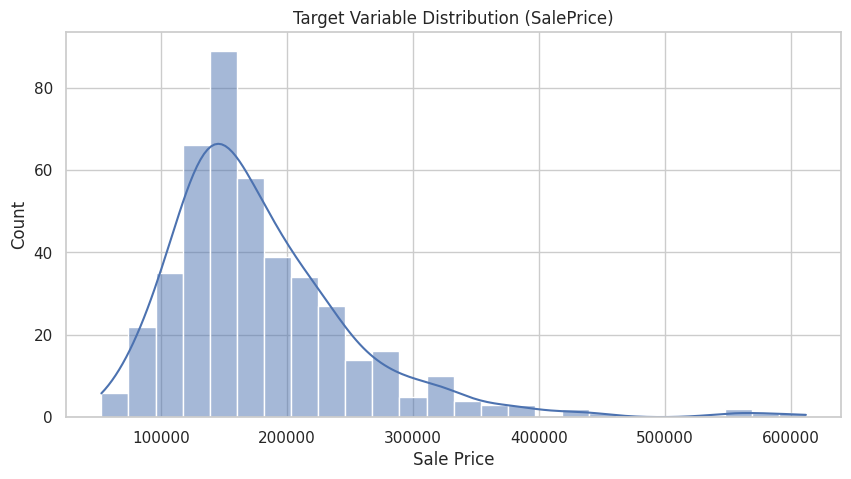

Skewness: 1.94


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# إعداد نمط الرسم
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))
sns.histplot(eda_sample['SalePrice'], kde=True)
plt.title('Target Variable Distribution (SalePrice)')
plt.xlabel('Sale Price')
plt.show()

print(f"Skewness: {eda_sample['SalePrice'].skew():.2f}")


## 5. التحقق من توازن الفئات (Categorical Imbalance)

من المهم جداً فحص المتغيرات الفئوية لمعرفة ما إذا كانت هناك فئات نادرة جداً.
وجود فئات نادرة قد يسبب مشاكل أثناء تقسيم البيانات (Train/Test Split) أو أثناء التحقق المتقاطع (Cross-Validation)، حيث قد تظهر الفئة في التدريب ولا تظهر في الاختبار، أو العكس.

**الحل:**
إذا وجدنا فئات نادرة، يمكننا دمجها في فئة "Other" أو استخدام معالجة قوية للأخطاء مثل `handle_unknown='ignore'` في `OneHotEncoder`.


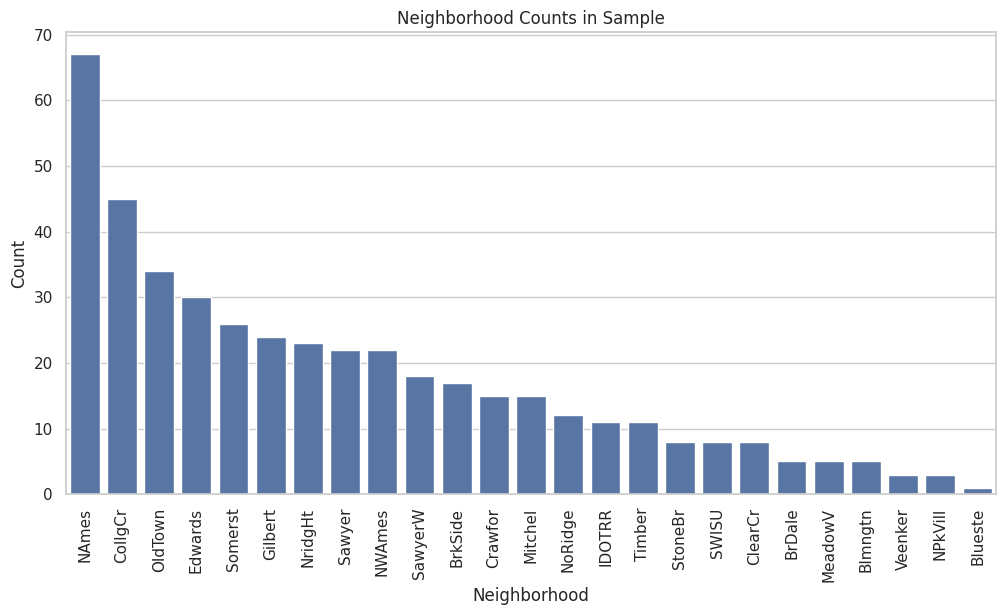

Number of rare neighborhoods (< 10): 9
Neighborhood
StoneBr    8
SWISU      8
ClearCr    8
BrDale     5
MeadowV    5
Blmngtn    5
Veenker    3
NPkVill    3
Blueste    1
Name: count, dtype: int64


In [14]:
plt.figure(figsize=(12, 6))
neighborhood_counts = eda_sample['Neighborhood'].value_counts()
sns.barplot(x=neighborhood_counts.index, y=neighborhood_counts.values)
plt.xticks(rotation=90)
plt.title('Neighborhood Counts in Sample')
plt.xlabel('Neighborhood')
plt.ylabel('Count')
plt.show()

# عرض الفئات النادرة (أقل من 10 مرات ظهور في العينة)
rare_threshold = 10
rare_neighborhoods = neighborhood_counts[neighborhood_counts < rare_threshold]
print(f"Number of rare neighborhoods (< {rare_threshold}): {len(rare_neighborhoods)}")
print(rare_neighborhoods)


## 6. العلاقة مع المتغير المستهدف

دعنا نرى كيف تؤثر مساحة الأرض (`LotArea`) على السعر. هذا يساعدنا في اكتشاف القيم الشاذة (Outliers).


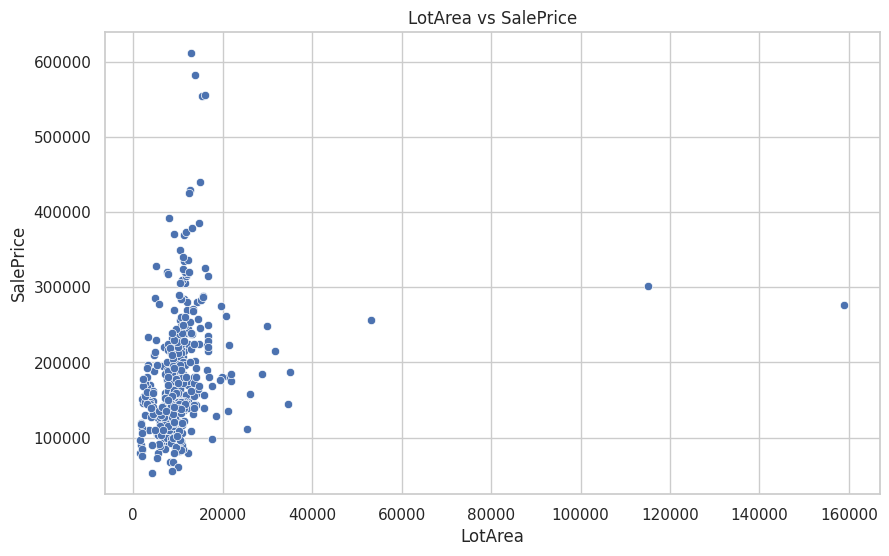

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_sample, x='LotArea', y='SalePrice')
plt.title('LotArea vs SalePrice')
plt.show()


## 7. قياس التعميم

أحد أهم المفاهيم في تعلم الآلة هو قدرة النموذج على **التعميم (Generalization)**، أي أداؤه على بيانات جديدة لم يرها أثناء التدريب.

### أخطاء شائعة

يقع الكثير من المبتدئين في خطأ فادح وهو تقييم النموذج على نفس البيانات التي تدرب عليها. هذا يعطي نتائج مضللة وتفاؤلية جداً.

### وضع مجموعة للاختبار

يجب تقسيم البيانات إلى قسمين:

1. **مجموعة التدريب (Training Set):** تُستخدم لتدريب النموذج.
2. **مجموعة الاختبار (Test Set):** تُحجب عن النموذج تماماً، وتُستخدم فقط في النهاية لتقييم أدائه.

In [16]:
from sklearn.model_selection import train_test_split

# تقسيم البيانات: 80% للتدريب و 20% للاختبار
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.2, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")

Shape of X_train: (1168, 80)
Shape of X_test: (292, 80)


## 8. مفاهيم Scikit-Learn الأساسية

تعتمد مكتبة Scikit-Learn على واجهة برمجية موحدة ومنظمة جداً. من أهم مكوناتها:

### 1. المُقدِّرات (Estimators)
المُقدِّر هو أي كائن يمكنه التعلم من البيانات. يتم ذلك عادةً باستخدام دالة `fit()`.
- مثال: `imputer.fit(data)` يتعلم القيم (مثل المتوسط) لاستخدامها في التعويض.

### 2. المُحوِّلات (Transformers)
هي نوع من المُقدِّرات يمكنه تحويل البيانات وتعديلها. 
- يتم ذلك باستخدام دالة `transform()`.
- أو دالة `fit_transform()` التي تقوم بالتعلم والتحويل في خطوة واحدة.
- مثال: `StandardScaler` يقوم بتعلم المتوسط والانحراف المعياري (`fit`) ثم يقوم بتوحيد البيانات (`transform`).

### 3. المتنبئات (Predictors)
هي مُقدِّرات قادرة على التنبؤ بقيم جديدة بناءً على ما تعلمته.
- تستخدم دالة `predict()` لإعطاء التنبؤات.
- تستخدم دالة `score()` لقياس جودة التنبؤ (مثلاً R² في الانحدار).
- مثال: `LinearRegression`، `DecisionTreeRegressor`.

## 9. المعالجة الأولية (Pre-processing)

نادراً ما تكون البيانات الخام جاهزة للاستخدام الفوري في نماذج تعلم الآلة. نحتاج غالباً إلى خطوات معالجة مثل:
- التعامل مع القيم المفقودة.
- ترميز المتغيرات الفئوية (Categorical Encoding).
- تقييس المتغيرات العددية (Scaling).

لنسهل الأمر، سنختر مجموعة محددة من الأعمدة للعمل عليها:

In [17]:
# تحديد الأعمدة العددية والفئوية
numeric_features = ["LotArea", "FullBath", "HalfBath", "YearBuilt"]
categorical_features = ["Neighborhood", "HouseStyle"]

# الاحتفاظ فقط بهذه الأعمدة للتبسيط
X_train = X_train[numeric_features + categorical_features]
X_test = X_test[numeric_features + categorical_features]

### أ. التعامل مع القيم المفقودة (Imputation)

القيم المفقودة مشكلة شائعة. لا تقبل معظم الخوارزميات وجود فراغات في البيانات.

**استراتيجيات التعويض (`SimpleImputer`):**

1. **`mean` (المتوسط):** تُستخدم مع البيانات العددية ذات التوزيع الطبيعي.
2. **`median` (الوسيط):** الأفضل للبيانات العددية التي تحتوي على قيم شاذة (Outliers).
3. **`most_frequent` (الأكثر تكراراً):** تُستخدم غالباً مع البيانات الفئوية (Categorical).
4. **`constant` (قيمة ثابتة):** تعويض القيمة المفقودة بقيمة محددة (مثلاً "Unknown" أو 0).

**كيف ندمجها في خط المعالجة؟**
عند استخدام `Pipeline`، نضمن أن عملية التعويض (`imputer.fit`) تتم فقط على بيانات التدريب، ثم تُطبق القواعد المستخلصة على بيانات الاختبار. هذا يمنع تسرب المعلومات.

### ب. تحويل الأعمدة (Column Transformers)

عادة ما تتطلب البيانات العددية معالجة مختلفة عن البيانات الفئوية.

- **الأعمدة العددية:** تحتاج لتعويض القيم المفقودة (مثلاً بالوسيط) ثم توحيد النطاق (`StandardScaler`).
- **الأعمدة الفئوية:** تحتاج لتعويض القيم المفقودة (مثلاً بالأكثر تكراراً) ثم ترميزها (`OneHotEncoder`).

تتيح لنا أداة `ColumnTransformer` تطبيق تحويلات مختلفة على أعمدة مختلفة في آن واحد.

In [18]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# 1. بناء خط معالجة للبيانات العددية
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),  # تعويض المفقود بالوسيط
        ("scaler", StandardScaler()),  # توحيد البيانات
    ]
)

# 2. بناء خط معالجة للبيانات الفئوية
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),  # تعويض المفقود بالأكثر تكراراً
        ("encoder", OneHotEncoder(handle_unknown="ignore")),  # ترميز الفئات
    ]
)

# 3. دمج الخطوتين باستخدام ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## 10. بناء النموذج النهائي (The Full Pipeline)

الآن سنقوم بدمج مرحلة المعالجة الأولية (`preprocessor`) مع نموذج انحدار (`Regressor`) في خط معالجة واحد متكامل.
سنستخدم نموذج **الانحدار التدريجي العشوائي (SGDRegressor)** كمثال.

In [19]:
from sklearn.linear_model import SGDRegressor

# بناء الخط الكامل: المعالجة + النموذج
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", SGDRegressor(random_state=42))
    ]
)

# عرض شكل خط المعالجة
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## 7. تدريب وتقييم النموذج

أصبح لدينا كائن واحد `pipeline` يتولى كل شيء.
- عند استدعاء `fit()`: سيقوم بتنفيذ خطوات المعالجة ثم تدريب النموذج.
- عند استدعاء `predict()` أو `score()`: سيقوم بمعالجة البيانات الجديدة بنفس الطريقة ثم التنبؤ.

In [20]:
# تدريب النموذج على بيانات التدريب
pipeline.fit(X_train, y_train)

# تقييم الأداء على بيانات الاختبار
score = pipeline.score(X_test, y_test)

print(f"R² Score on Test Set: {score:.3f}")

R² Score on Test Set: 0.668


بهذه الطريقة، قمنا ببناء نظام متكامل قابل لإعادة الاستخدام، يضمن معالجة صحيحة للبيانات ويمنع الأخطاء الشائعة مثل تسرب البيانات، كل ذلك بأسلوب برمجي منظم.